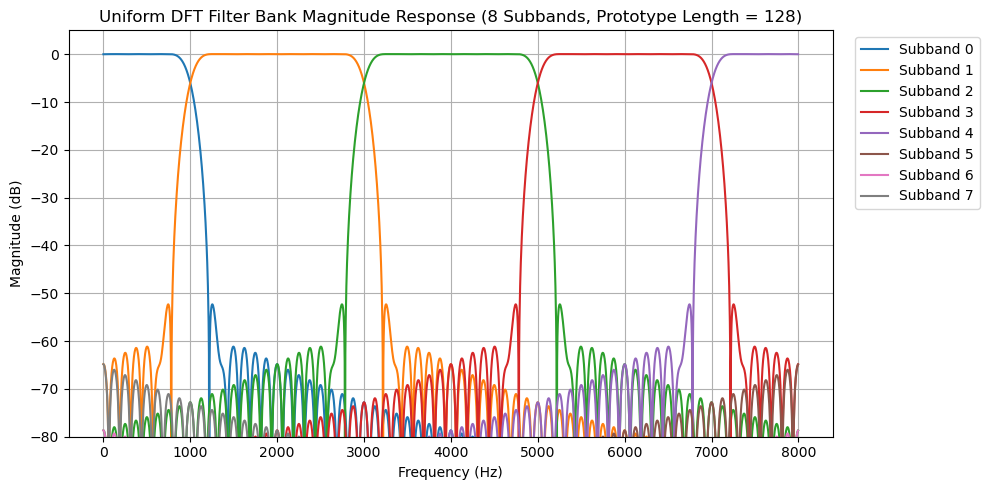

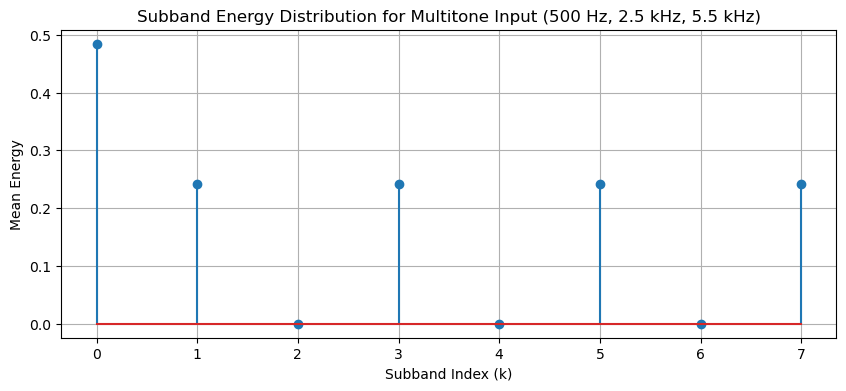

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, freqz, lfilter

# example 2.4
class UniformDFTFilterBank:
    """
    N-channel Uniform DFT Analysis Filter Bank using Polyphase Decomposition
    Prototype filter P(z) is modulated to create N subband channels.
    """
    def __init__(self, N: int, M: int, prototype_taps: np.ndarray):
        self.N = N  # Number of channels/subbands
        self.M = M  # Decimation factor (M <= N)
        self.p0 = prototype_taps  
        self.L = len(prototype_taps)
        
        
        pad_len = int(np.ceil(self.L / N)) * N - self.L
        if pad_len > 0:
            self.p0 = np.pad(self.p0, (0, pad_len))
            self.L += pad_len
            
        self.num_poly_taps = self.L // N
        
        self.E = self.p0.reshape((self.N, self.num_poly_taps), order='F')

    def analyze_fullband(self, x: np.ndarray):
        """
        Standard modulated filtering for reference:
        H_k(z) = P_0(z * exp(-j 2pi k / N))
        """
        N_samples = len(x)
        subbands = np.zeros((self.N, N_samples), dtype=complex)
        n = np.arange(self.L)
        
        for k in range(self.N):
            # Modulation factor
            hk = self.p0 * np.exp(1j * 2 * np.pi * k * n / self.N)
            subbands[k, :] = lfilter(hk, 1, x)
            
        
        subbands_dec = subbands[:, ::self.M]
        return subbands, subbands_dec


# 2. Example 2.4 Setup & Execution

# Filter Bank Parameters
N = 8      # 8 Subbands
M = 4      # Downsampling factor (Critically sampled if M=N=8, Oversampled if M=4)
L_p = 128  # Prototype filter length


fs = 16000
fc = fs / (2 * N)
p0 = firwin(L_p, cutoff=fc, fs=fs, window='hamming')

# Instantiate Filter Bank
fb = UniformDFTFilterBank(N=N, M=M, prototype_taps=p0)


t = np.arange(2048) / fs
x_test = (np.sin(2 * np.pi * 500 * t) + 
          np.sin(2 * np.pi * 2500 * t) + 
          np.sin(2 * np.pi * 5500 * t))


subbands_full, subbands_dec = fb.analyze_fullband(x_test)


# 3. Frequency Response Plotting

plt.figure(figsize=(10, 5))
n_fft = 2048


n = np.arange(len(p0))
for k in range(N):
    hk = p0 * np.exp(1j * 2 * np.pi * k * n / N)
    w, h = freqz(hk, worN=n_fft, fs=fs)
    plt.plot(w, 20 * np.log10(np.abs(h) + 1e-12), label=f'Subband {k}')

plt.title(f'Uniform DFT Filter Bank Magnitude Response ({N} Subbands, Prototype Length = {L_p})')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.ylim([-80, 5])
plt.grid(True)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
subband_energies = np.mean(np.abs(subbands_dec)**2, axis=1)
plt.stem(range(N), subband_energies)
plt.title('Subband Energy Distribution for Multitone Input (500 Hz, 2.5 kHz, 5.5 kHz)')
plt.xlabel('Subband Index (k)')
plt.ylabel('Mean Energy')
plt.grid(True)
plt.show()